# Limpieza y normalización del dataset

## Carga del dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler, OneHotEncoder



df = pd.read_csv('../docs/avocado.csv')
df_copy = df.copy()
df.head()


,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


## Exploración inicial del data set

### Información y estadísticas descriptivas

In [ ]:
print("Información y estadísticas descriptivas")
df.info()
df.describe()

Información y estadísticas descriptivas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  object 
 12  year          18249 non-null  int64  
 13  region        18249 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 1.9+ MB


,Unnamed: 0,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year
count,18249.000000,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,18249.000000
mean,24.232232,1.405978,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507,2016.147899
std,15.481045,0.402677,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652,0.939938
min,0.000000,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2015.000000
25%,10.000000,1.100000,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,5.088640e+03,2.849420e+03,1.274700e+02,0.000000,2015.000000
50%,24.000000,1.370000,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,3.974383e+04,2.636282e+04,2.647710e+03,0.000000,2016.000000
75%,38.000000,1.660000,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,1.107834e+05,8.333767e+04,2.202925e+04,132.500000,2017.000000
max,52.000000,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000


### Caracteristicas

In [ ]:
print(f"Dimensiones del dataset: {df.shape}")
print(f"Filas duplicadas: {df.duplicated().sum()}")
print(f"\nValores nulos por columna:")
print(df.isnull().sum())
print()

Dimensiones del dataset: (18249, 14)
Filas duplicadas: 0

Valores nulos por columna:
Unnamed: 0      0
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64



### Ya que el dataset no tiene valores nulos no necesitamos hacer ningun manejo de estos

## Corrección de columnas de texto
### Para evitar inconsistencias por diferencias en mayusculas o espacios normalizamos las columnas de texto para esto empezamos verificando las inconsistencias

In [ ]:
print(f"Valores de la columna {df.region.value_counts()}")
print(f"Valores de la columna {df.type.value_counts()}")

Valores de la columna region
Albany                 338
Atlanta                338
BaltimoreWashington    338
Boise                  338
Boston                 338
BuffaloRochester       338
California             338
Charlotte              338
Chicago                338
CincinnatiDayton       338
Columbus               338
DallasFtWorth          338
Denver                 338
Detroit                338
GrandRapids            338
GreatLakes             338
HarrisburgScranton     338
HartfordSpringfield    338
Houston                338
Indianapolis           338
Jacksonville           338
LasVegas               338
LosAngeles             338
Louisville             338
MiamiFtLauderdale      338
Midsouth               338
Nashville              338
NewOrleansMobile       338
NewYork                338
Northeast              338
NorthernNewEngland     338
Orlando                338
Philadelphia           338
PhoenixTucson          338
Pittsburgh             338
Plains                 338

### Aunque aparentemente no hay inconsistencias procedemos a unificar mayusculas y elimnar espacios para asegurar que no haya errores

In [ ]:
df['region'] = df['region'].str.strip().str.upper()
df['type'] = df['type'].str.strip().str.upper()

## Transformación de fechas
### Ahora transformamos la columna de fecha a un tipo de dato de fecha para poder analizarlo fácilmente

In [ ]:
#Eliminamos la columna año que aporta información que ya tenemos
df.drop(columns=['year'])
df['Date'] = pd.to_datetime(df['Date'])

# Extraer componentes temporales
df['day'] = ['Date'].dt.day
df['week']  = ['Date'].dt.isocalendar().week.astype(int)
df['month'] = ['Date'].dt.month
df['year'] = ['date'].dt.year

#Eliminamos la columna date que ya no aporta información
df = df.drop(columns=['Date'])
df.head()

<class 'pandas.core.series.Series'>
RangeIndex: 18249 entries, 0 to 18248
Series name: Date
Non-Null Count  Dtype         
--------------  -----         
18249 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 142.7 KB


## Tratamiento de valores atipicos
### Usaremos las 2 estrategias para identificar los valores atipicos y elegirimos la que mejor normalice la distribución

### Primero eliminamos la columna sin nombre ya que solo representa un indice lo cual no aporatará nada a las predicciones

In [ ]:
df.drop(columns=['Unnamed: 0'], inplace = True)
df.head()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,CONVENTIONAL,2015,ALBANY
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,CONVENTIONAL,2015,ALBANY
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,CONVENTIONAL,2015,ALBANY
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,CONVENTIONAL,2015,ALBANY
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,CONVENTIONAL,2015,ALBANY


### Detección de datos atipicos con rango intercuartil

In [ ]:
Q1, Q3 = df['AveragePrice'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lim_inf, lim_sup = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
print(lim_inf, lim_sup)

0.26000000000000034 2.4999999999999996


### Detección de datos atipicos con Z-score

In [ ]:
z_scores = np.abs(stats.zscore(df['AveragePrice']))
threshold = 3
outliers = df[z_scores > threshold]
print(f"Outliers detectados con Z-score > {threshold}: {len(outliers)}")
outliers[['AveragePrice', 'type']]

Outliers detectados con Z-score > 3: 131


,AveragePrice,type
11320,2.79,ORGANIC
11321,2.66,ORGANIC
11323,2.74,ORGANIC
11324,2.79,ORGANIC
11325,2.73,ORGANIC
...,...,...
17302,2.81,ORGANIC
17303,2.84,ORGANIC
17304,2.64,ORGANIC
17402,2.70,ORGANIC


### Viendo estó y teniendo en cuenta lo que se evidenció en el analisis previo nos damos cuenta que si hacemos esto perderemos datos valioso porque no estamos teniendo en cuenta que entre los aguacates convencionales y organicos hay 2 distribuciones diferentes entonces vamos a eliminar los valores atipicos de cada distribucion por aparte

In [ ]:
df_filtrado = pd.DataFrame()

for i in df['type'].unique():
    subset = df[df['type'] == i]
    
    Q1 = subset['AveragePrice'].quantile(0.25)
    Q3 = subset['AveragePrice'].quantile(0.75)
    IQR = Q3 - Q1
    
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    
    subset_filtrado = subset[
        (subset['AveragePrice'] >= lim_inf) &
        (subset['AveragePrice'] <= lim_sup)
    ]
    
    df_filtrado = pd.concat([df_filtrado, subset_filtrado])

df_filtrado.head()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,CONVENTIONAL,2015,ALBANY
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,CONVENTIONAL,2015,ALBANY
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,CONVENTIONAL,2015,ALBANY
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,CONVENTIONAL,2015,ALBANY
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,CONVENTIONAL,2015,ALBANY


Dimensiones antes de limpiar: (18249, 13)
Dimensiones después de limpiar: (17934, 13)


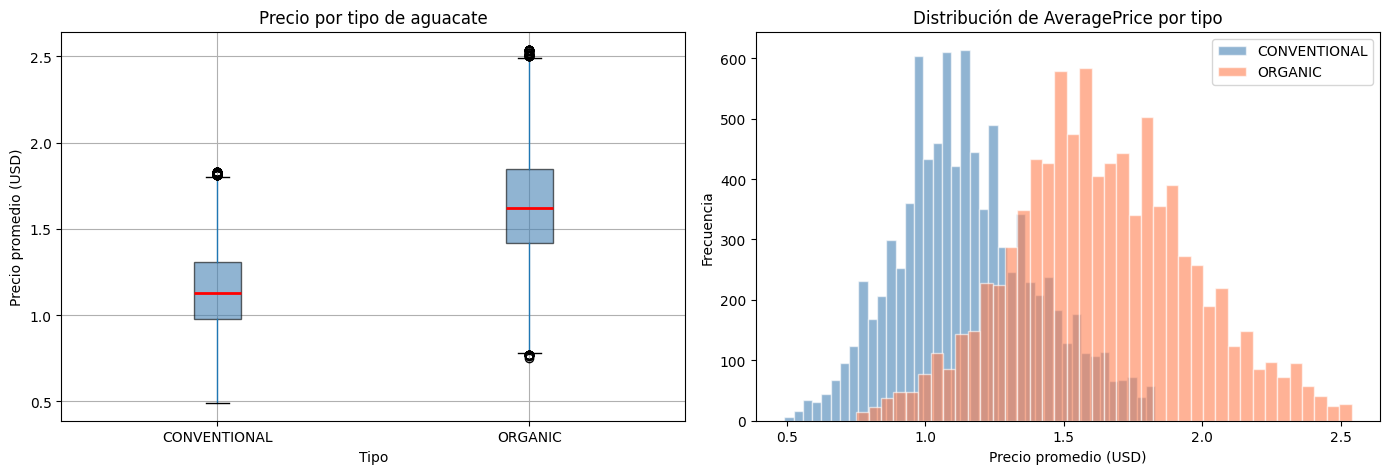

In [ ]:
print("Dimensiones antes de limpiar:", df.shape)
print("Dimensiones después de limpiar:", df_filtrado.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_filtrado.boxplot(column='AveragePrice', by='type', ax=axes[0],
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6),
           medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Distribución de precio por tipo')
axes[0].set_xlabel('Tipo')
axes[0].set_ylabel('Precio promedio (USD)')
plt.sca(axes[0])
plt.title('Precio por tipo de aguacate')

for tipo, color in zip(['CONVENTIONAL', 'ORGANIC'], ['steelblue', 'coral']):
    subset = df_filtrado[df_filtrado['type'] == tipo]['AveragePrice']
    axes[1].hist(subset, bins=40, alpha=0.6, label=tipo, color=color, edgecolor='white')

axes[1].set_title('Distribución de AveragePrice por tipo')
axes[1].set_xlabel('Precio promedio (USD)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.suptitle('')
plt.tight_layout()
plt.savefig('precio_por_tipo.png', dpi=150, bbox_inches='tight')
plt.show()

### Por ultimo para eliminar las distribuciones de cola pesada que presentan las varibables de volumen usaremos una transformación logartimica para no perder datos importates ya que las colas representan datos que no se pueden desestimar ya que estan relacionados con las regiones

In [ ]:
cols_volumen = ['Total Volume', '4046', '4225', '4770',
                'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags']

for col in cols_volumen:
    df_filtrado[col] = np.log1p(df[col])

df_filtrado.head()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-12-27,1.33,11.070344,6.944801,10.905146,3.895080,9.070833,9.060055,4.545951,0.0,CONVENTIONAL,2015,ALBANY
1,2015-12-20,1.35,10.912867,6.515127,10.706381,4.083115,9.159737,9.149429,4.589955,0.0,CONVENTIONAL,2015,ALBANY
2,2015-12-13,0.93,11.680313,6.679222,11.600485,4.879007,9.005325,8.992584,4.645736,0.0,CONVENTIONAL,2015,ALBANY
3,2015-12-06,1.08,11.277116,7.032624,11.184108,4.298373,8.667708,8.644425,4.903495,0.0,CONVENTIONAL,2015,ALBANY
4,2015-11-29,1.28,10.840377,6.848515,10.688288,4.340944,8.729874,8.697389,5.291746,0.0,CONVENTIONAL,2015,ALBANY


## Estandarización y normalización de datos númericos
### Ahora vamos a tomar las columnas númericas y estandarizar para acercar sus escalas, usaremos la estrategia Z-score ya que no buscamos ningun rango especifico en ninguna columna como para usar min-max

In [ ]:
scaler = StandardScaler()

cols_numericas = ['AveragePrice'] + cols_volumen

df_filtrado[cols_numericas] = scaler.fit_transform(df_filtrado[cols_numericas])
df_filtrado.head()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-12-27,-0.162848,-0.115021,-0.616377,0.369351,-0.286600,-0.504590,-0.260728,-0.671562,-0.646579,CONVENTIONAL,2015,ALBANY
1,2015-12-20,-0.110121,-0.183584,-0.744123,0.299899,-0.241293,-0.465177,-0.225881,-0.660104,-0.646579,CONVENTIONAL,2015,ALBANY
2,2015-12-13,-1.217387,0.150551,-0.695336,0.612314,-0.049524,-0.533632,-0.287034,-0.645580,-0.646579,CONVENTIONAL,2015,ALBANY
3,2015-12-06,-0.821935,-0.024995,-0.590266,0.466825,-0.189427,-0.683308,-0.422779,-0.578466,-0.646579,CONVENTIONAL,2015,ALBANY
4,2015-11-29,-0.294666,-0.215146,-0.645003,0.293577,-0.179170,-0.655747,-0.402128,-0.477375,-0.646579,CONVENTIONAL,2015,ALBANY


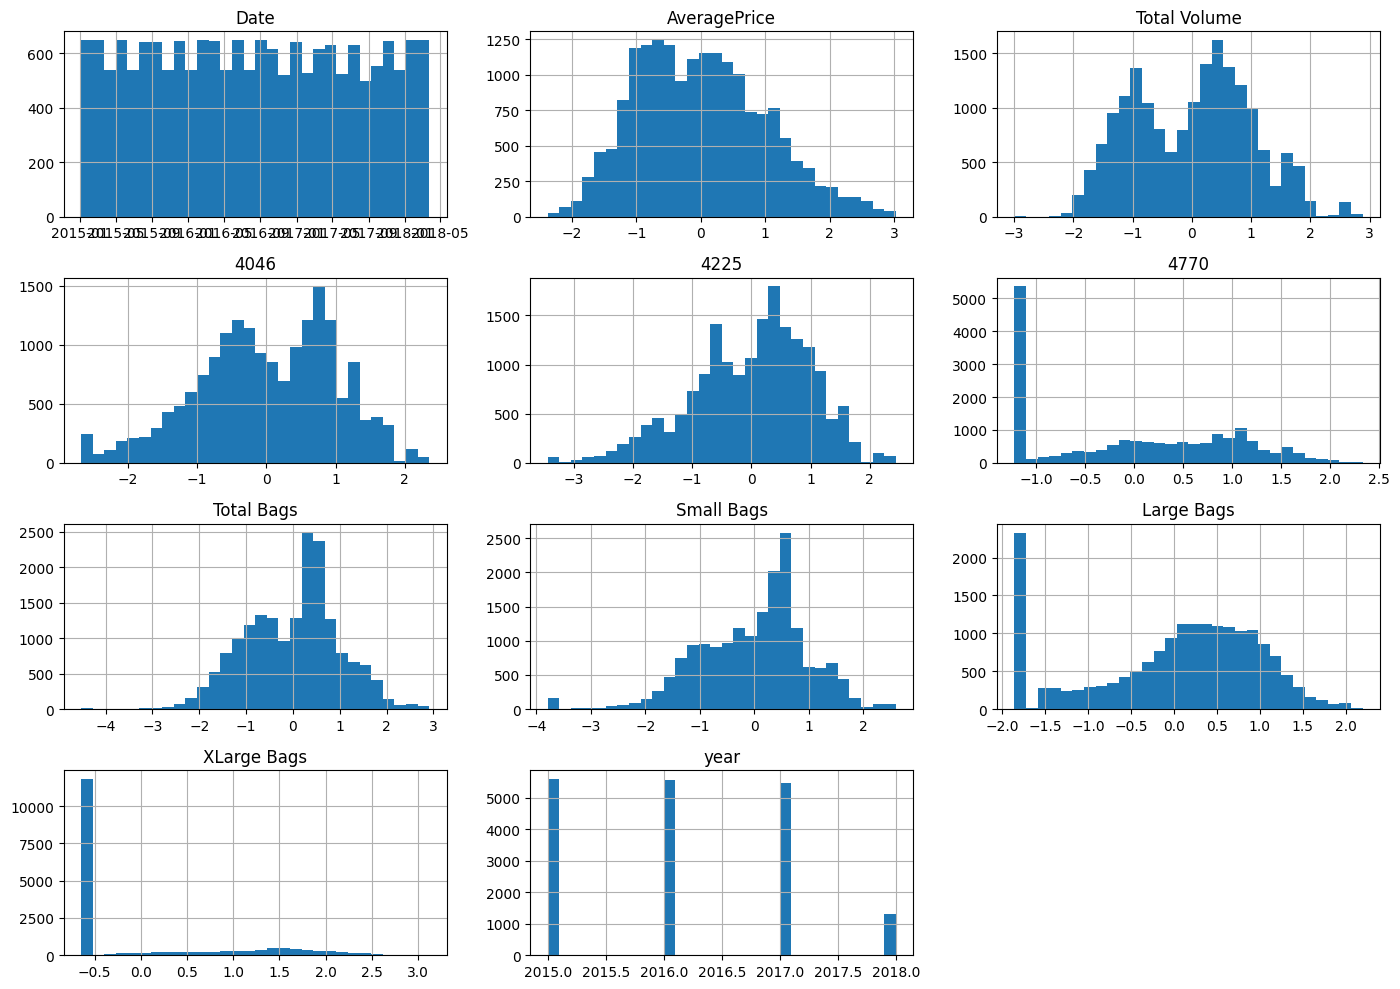

In [ ]:
df_filtrado.hist(figsize=(14, 10), bins=30)
plt.tight_layout()

## Codificación de columnas categoricas o de texto
### Utilizaremos One-Hot encoder para convertir las categorias en columnas binarias (0/1) llamadas dummies

In [ ]:
cols_categorics = ['type', 'region']

encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
encoded_categories= encoder.fit_transform(df_filtrado[cols_categorics])
categoric_columns = encoder.get_feature_names_out(cols_categorics)
encoded_df = pd.DataFrame(encoded_categories, columns=categoric_columns, index=df_filtrado.index)

# Unir las columnas codificadas al DataFrame
df_filtrado = pd.concat([df_filtrado, encoded_df], axis=1)

print(f"Columnas dummy creadas: {list(categoric_columns)}")
print(f"(La categoría base excluida por drop='first' actúa como referencia)")
df_filtrado.head()

Columnas dummy creadas: ['type_ORGANIC', 'region_ATLANTA', 'region_BALTIMOREWASHINGTON', 'region_BOISE', 'region_BOSTON', 'region_BUFFALOROCHESTER', 'region_CALIFORNIA', 'region_CHARLOTTE', 'region_CHICAGO', 'region_CINCINNATIDAYTON', 'region_COLUMBUS', 'region_DALLASFTWORTH', 'region_DENVER', 'region_DETROIT', 'region_GRANDRAPIDS', 'region_GREATLAKES', 'region_HARRISBURGSCRANTON', 'region_HARTFORDSPRINGFIELD', 'region_HOUSTON', 'region_INDIANAPOLIS', 'region_JACKSONVILLE', 'region_LASVEGAS', 'region_LOSANGELES', 'region_LOUISVILLE', 'region_MIAMIFTLAUDERDALE', 'region_MIDSOUTH', 'region_NASHVILLE', 'region_NEWORLEANSMOBILE', 'region_NEWYORK', 'region_NORTHEAST', 'region_NORTHERNNEWENGLAND', 'region_ORLANDO', 'region_PHILADELPHIA', 'region_PHOENIXTUCSON', 'region_PITTSBURGH', 'region_PLAINS', 'region_PORTLAND', 'region_RALEIGHGREENSBORO', 'region_RICHMONDNORFOLK', 'region_ROANOKE', 'region_SACRAMENTO', 'region_SANDIEGO', 'region_SANFRANCISCO', 'region_SEATTLE', 'region_SOUTHCAROLINA', 

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,...,region_SOUTHCAROLINA,region_SOUTHCENTRAL,region_SOUTHEAST,region_SPOKANE,region_STLOUIS,region_SYRACUSE,region_TAMPA,region_TOTALUS,region_WEST,region_WESTTEXNEWMEXICO
0,2015-12-27,-0.162848,-0.115021,-0.616377,0.369351,-0.286600,-0.504590,-0.260728,-0.671562,-0.646579,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2015-12-20,-0.110121,-0.183584,-0.744123,0.299899,-0.241293,-0.465177,-0.225881,-0.660104,-0.646579,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2015-12-13,-1.217387,0.150551,-0.695336,0.612314,-0.049524,-0.533632,-0.287034,-0.645580,-0.646579,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2015-12-06,-0.821935,-0.024995,-0.590266,0.466825,-0.189427,-0.683308,-0.422779,-0.578466,-0.646579,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2015-11-29,-0.294666,-0.215146,-0.645003,0.293577,-0.179170,-0.655747,-0.402128,-0.477375,-0.646579,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Por ultimo eliminamos las columnas originales que transformamos en dummies

In [ ]:
df_filtrado.drop(columns=cols_categorics, inplace=True)

### Y así quedaria nuestro dataset final

In [ ]:
print(f"Dataset final: {df_filtrado.shape}")
df_filtrado.head(10)

Dataset final: (17934, 65)


,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,...,region_SOUTHCAROLINA,region_SOUTHCENTRAL,region_SOUTHEAST,region_SPOKANE,region_STLOUIS,region_SYRACUSE,region_TAMPA,region_TOTALUS,region_WEST,region_WESTTEXNEWMEXICO
0,2015-12-27,-0.162848,-0.115021,-0.616377,0.369351,-0.286600,-0.504590,-0.260728,-0.671562,-0.646579,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2015-12-20,-0.110121,-0.183584,-0.744123,0.299899,-0.241293,-0.465177,-0.225881,-0.660104,-0.646579,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2015-12-13,-1.217387,0.150551,-0.695336,0.612314,-0.049524,-0.533632,-0.287034,-0.645580,-0.646579,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2015-12-06,-0.821935,-0.024995,-0.590266,0.466825,-0.189427,-0.683308,-0.422779,-0.578466,-0.646579,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2015-11-29,-0.294666,-0.215146,-0.645003,0.293577,-0.179170,-0.655747,-0.402128,-0.477375,-0.646579,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,2015-11-22,-0.347392,-0.174922,-0.576857,0.325760,-0.310001,-0.621286,-0.366659,-0.590973,-0.646579,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,2015-11-15,-1.059206,-0.001073,-0.533812,0.474964,-0.129748,-0.524289,-0.279611,-0.602135,-0.646579,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,2015-11-08,-1.085570,0.116905,-0.731423,0.588009,-0.166278,-0.611752,-0.384271,-0.206015,-0.646579,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,2015-11-01,-0.980116,0.076856,-0.620586,0.534328,-0.150894,-0.385068,-0.161249,-0.383602,-0.646579,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,2015-10-25,-0.848298,-0.051430,-0.678027,0.429896,-0.083933,-0.508222,-0.286102,-0.205055,-0.646579,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df_filtrado.to_csv("../docs/clean_avocado.csv", index=False)